In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [2]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [3]:
df_agn = load_quasar_data("data/aug3_fhostshen11_N10t8w2000s1000_merged.h5", populate_sdss=False)

print(list(df_agn.keys()))


Reading quasars from HDF5: 100%|██████████| 88/88 [00:00<00:00, 412.18it/s]

Number of quasars loaded: 88
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'color', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'chi_sq']
Before dropping NaNs and infs, number of quasars: 88
Number of quasars with 0 < z <= 0.5: 3
Number of quasars with z > 3: 3
Before data cuts, number of quasars: 88
Number of quasars with 0 < z <= 0.5: 3
Number of quasars with z > 3: 3
Number of quasars with 0 < z <= 0.5: 0
Number of dropped quasars with 0 < z <= 0.5: 3
Number of quasars with z > 3: 0
Final number of quasars: 82
['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL

In [4]:
import hubble_fit
cosmo_model = 'FlatwCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, fitting_method='dynesty', cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=False,resume=True)


log tau UV RF pivot:  2.358755773498562
log sigma hat sq pivot:  -4.294686940908076
alpha_nu pivot:  -0.5
z mean: 1.582,  z_agn_pivot: 1.521
Fraction of finite likelihoods: 1.0

Bayesian evidence logZ = 746.37 ± 0.39
Dynesty results stats:
  samples shape: (4167, 13)
  weights max: 0.0013083934785612338
  effective samples: 1124.3013938253719
       gamma_sn: 0.0075 (+0.0103, -0.0098)
         tau_Ms: 0.1038 (+0.0662, -0.0637)
          M0_sn: -19.2432 (+0.0243, -0.0266)
         M0_agn: -20.3324 (+0.2411, -0.4917)
log_sigma_hat_sq_break: -1.1184 (+0.3757, -0.2058)
     eta_A1_agn: 0.6173 (+0.1134, -0.1383)
     eta_A2_agn: 0.8978 (+2.8177, -1.9490)
  eta_break_agn: 5.7350 (+2.9403, -3.6524)
       beta_agn: 0.0696 (+0.2462, -0.2398)
          log_f: -0.3729 (+0.0883, -0.0792)
             H0: 73.5940 (+0.8329, -0.8768)
            Om0: 0.3675 (+0.0469, -0.0514)
             w0: -1.0803 (+0.1366, -0.1720)


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/dynesty/dynamicsampler.py:2046: RuntimeWarning: You tried to resume the run that has ended successfully.
This is not supported. No sampling was performed
  warnings.warn(


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/tutorials/hubble_plotting.py:488: UserWarning: 

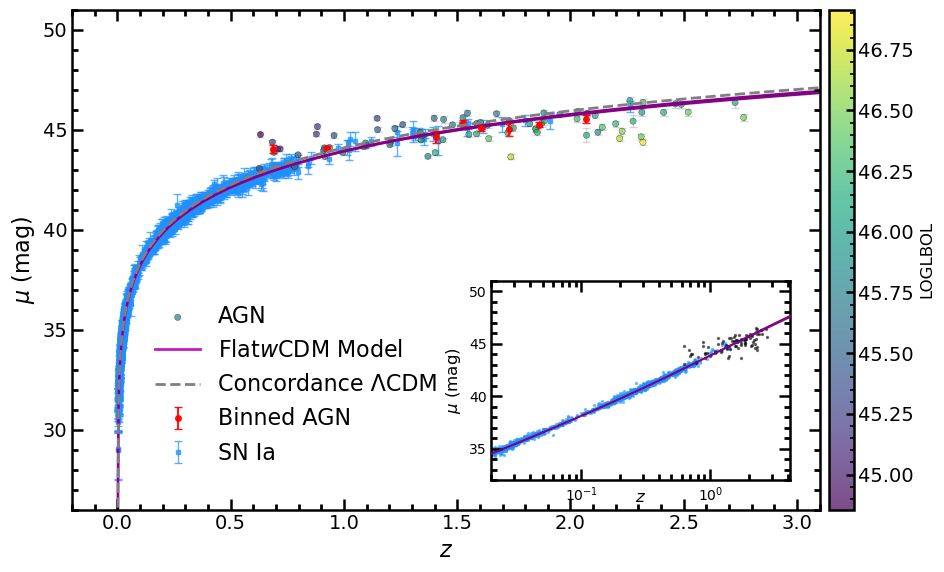

In [5]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, show_true=False)

Reduced chi^2: 31.502


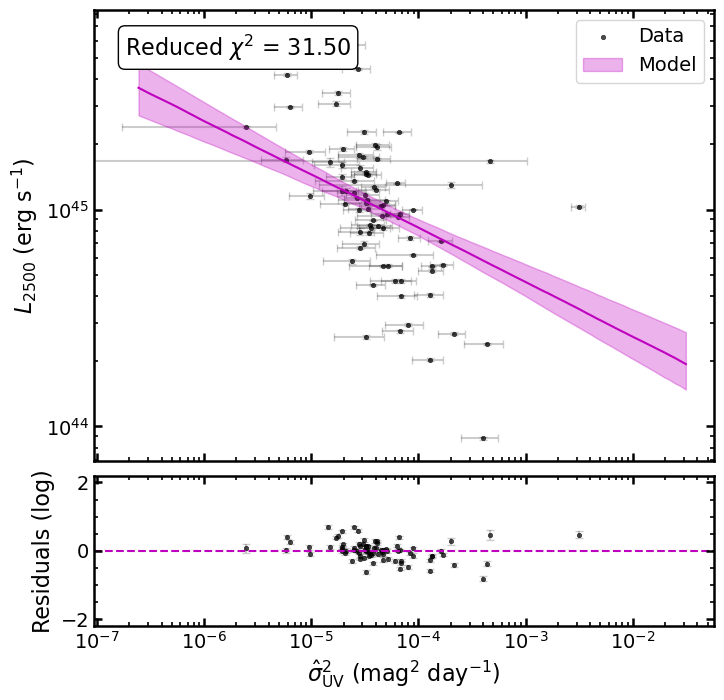

In [6]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)

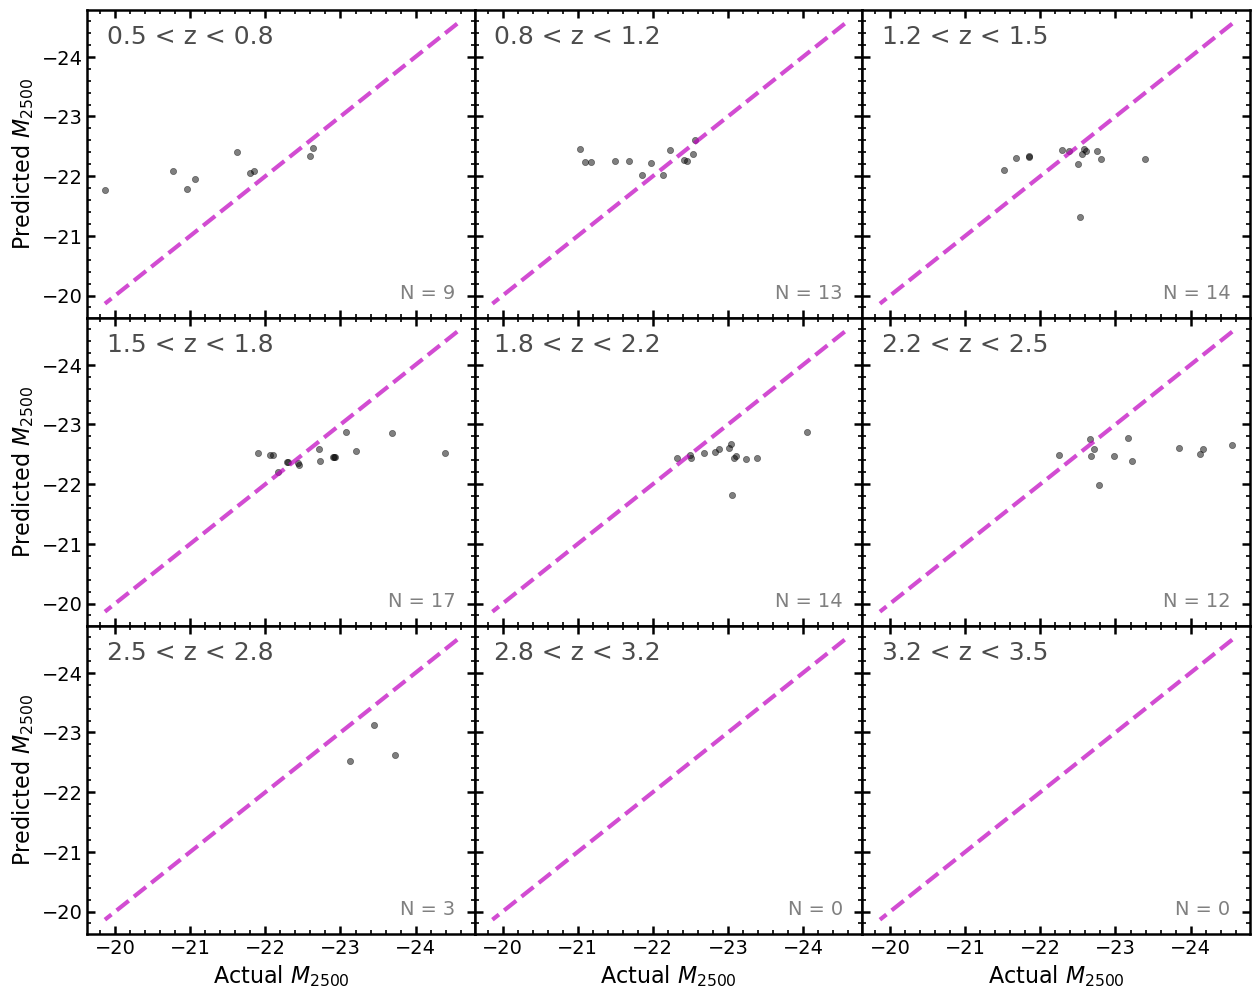

In [7]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, cosmo_model, show=True)

Fitted parameters:
  x_break: -1.5000
  d1: 3.0000
  d2: -1.0000
  M0: -20.0000
  ds: 0.0188


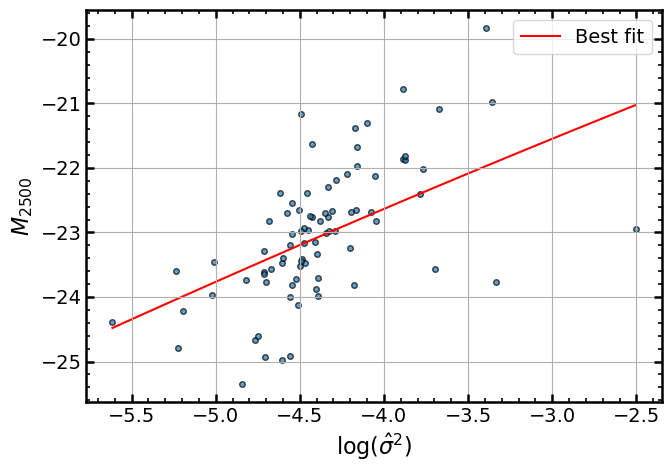

In [8]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def broken_power_law(x, x_break, d1, d2, M0, ds):
    """Broken power law defined to be zero at x_break.
    That decorrelates d1, d2 from M0_agn.
    """
    #print(f"broken_power_law: x={x}, x_break={x_break}, d1={d1}, d2={d2}, ds={ds}")
    delta = x - x_break
    term = (d2 - d1) / ds * np.log10(1 + 10**(ds * delta))
    offset = (d2 - d1) / ds * np.log10(2)  # value of the term when delta = 0
    return d1 * delta + term - offset + M0

d = df_agn[df_agn['LOGL2500'] > 0]  # Filter to only include objects with LOGL2500 < 0
initial_guess = [-1.1, 4, 0, -27, 2]
M_2500_actual = -2.5 * d['LOGL2500'] + 90

params, cov = curve_fit(
    broken_power_law,
    2*d['log_sigma_hat_UV'],
    M_2500_actual,
    p0=initial_guess,
    bounds=([-1.5, 3, -1, -30, 0], [-0.8, 6, 2, -20, 100])
)

print("Fitted parameters:")
for name, value in zip(['x_break', 'd1', 'd2', 'M0', 'ds'], params):
    print(f"  {name}: {value:.4f}")

x_fit = np.linspace((2*d['log_sigma_hat_UV']).min(), (2*d['log_sigma_hat_UV']).max(), 200)
y_fit = broken_power_law(x_fit, *params)

plt.figure(figsize=(7, 5))
plt.scatter(2*d['log_sigma_hat_UV'], M_2500_actual, alpha=0.7, edgecolor='k', zorder=-2)
plt.plot(x_fit, y_fit, color='red', label='Best fit', zorder=-1)

plt.legend()
plt.xlabel(r'$\log(\hat{\sigma}^2)$')
plt.ylabel(r'$M_{2500}$')
plt.grid(True)
plt.tight_layout()
plt.show()